In [20]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [21]:
rfm = pd.read_csv("../data/processed/rfm_customers.csv")
rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,12346.0,325,1,77183.60,1,1,4,114,at_risk
1,12347.0,1,7,4310.00,4,4,4,444,loyal
2,12348.0,74,4,1797.24,2,3,4,234,loyal
3,12349.0,18,1,1757.55,3,1,4,314,at_risk
4,12350.0,309,1,334.40,1,1,2,112,at_risk


In [22]:
rfm_features = rfm[["recency", "frequency", "monetary"]]

In [23]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

In [25]:
rfm.groupby("cluster")[["recency","frequency","monetary"]].mean()

,recency,frequency,monetary
cluster,,,
0,14.371429,21.861905,12444.119905
1,247.564030,1.551789,478.107581
2,6.384615,81.846154,127338.313846
3,42.922069,3.648003,1353.960181


In [26]:
rfm["cluster"].value_counts()

cluster
3    3054
1    1062
0     210
2      13
Name: count, dtype: int64

Elbow Method:

In [32]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1,11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

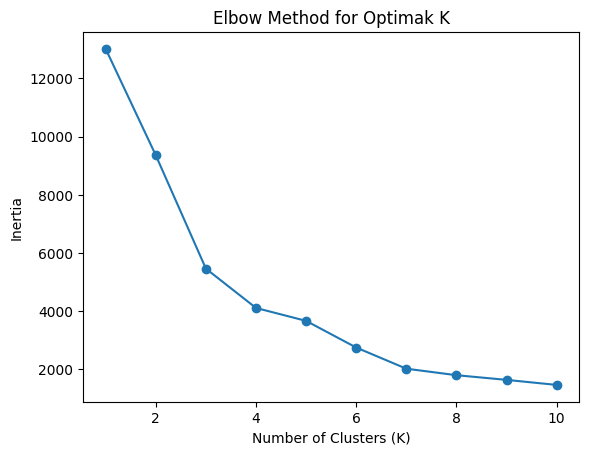

In [33]:
import matplotlib.pyplot as plt

plt.plot(K_range, inertia, marker="o")

plt.title("Elbow Method for Optimak K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [34]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

In [36]:
rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean()

,recency,frequency,monetary
cluster,,,
0,14.371429,21.861905,12444.119905
1,247.564030,1.551789,478.107581
2,6.384615,81.846154,127338.313846
3,42.922069,3.648003,1353.960181
